# Multi3Hate — Complete Notebook for Integrated Gradients + Qualitative Error Analysis

This notebook is a **standalone continuation/reproduction notebook** prepared from the uploaded
`multi3hate_debiasing_colab_deduped (1).ipynb`.

It contains only the dependencies and pipeline components required for:

1. **Integrated Gradients modality analysis** on the corrected real-image + real-caption pipeline.
2. **Qualitative error analysis** comparing the independently trained baseline and proposed debiased model.

### Important
- The original notebook's corrected pipeline uses **OpenCLIP ViT-B/32**, producing a 512-d image
  feature + 512-d text feature = **1024-d fused feature**.
- The corrected dataset uses real per-culture captions and real image paths.
- The original hyperparameter search recorded the best configuration as:
  - learning rate = `1e-4`
  - hidden dimension = `512`
  - adversarial lambda = `0.2`
- This notebook therefore does **not** repeat the 27-combination hyperparameter search.
- If the previously saved debiased checkpoint exists, it is loaded. Otherwise the final debiased
  model is retrained.
- The baseline is retrained because the original notebook did not save a baseline checkpoint.

In [1]:
#@title 1. Install only the dependencies needed for this notebook
# Colab: run this cell first.

!pip install -q open-clip-torch captum scikit-learn pandas matplotlib pillow tqdm

import os
import sys
import copy
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
#@title 2. Reproducibility + paths

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path("/content/Multi3Hate")
MEME_DIR = BASE_DIR / "data" / "memes"
CAPTIONS_DIR = BASE_DIR / "data" / "captions"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"
MODELS_DIR = BASE_DIR / "models"

for p in [BASE_DIR, RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEBIAS_CHECKPOINT = MODELS_DIR / "adversarial_debiased_model_best.pt"
BASELINE_CHECKPOINT = MODELS_DIR / "baseline_model_best.pt"

print("Device:", device)
print("Base directory:", BASE_DIR)

Device: cuda
Base directory: /content/Multi3Hate


In [4]:
import subprocess
import shutil # Added import

if not (BASE_DIR / ".git").exists():
    print("Cloning Multi3Hate repository...")
    # The directory is created above. Clone into it only if it is not already a git repo.
    # If BASE_DIR exists and is not a git repo, remove it to allow cloning.
    if BASE_DIR.is_dir(): # Check if it's a directory
        shutil.rmtree(BASE_DIR) # Remove the directory and its contents

    subprocess.run(
        ["git", "clone", "https://github.com/MinhDucBui/Multi3Hate.git", str(BASE_DIR)],
        check=True
    )
else:
    print("Repository already exists.")

# Re-create output folders because cloning may have created the repository tree.
for p in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Repository:", BASE_DIR)
print("MEME_DIR exists:", MEME_DIR.exists())
print("CAPTIONS_DIR exists:", CAPTIONS_DIR.exists())

Cloning Multi3Hate repository...
Repository: /content/Multi3Hate
MEME_DIR exists: True
CAPTIONS_DIR exists: True


## 4. Corrected data construction

This reproduces the important corrected section of the uploaded notebook rather than the older
broken reconstruction. The image path is obtained by scanning the real image folders; captions
come from the real language-specific caption CSVs; labels come from `final_annotations.csv`.

The notebook refuses to continue if images/captions are missing or if the corrected validation
conditions fail.

In [6]:
#@title 4. Build the corrected real-image + real-caption dataset

CULTURE_TO_LANG = {
    "US": "en",
    "DE": "de",
    "MX": "es",
    "CN": "zh",
    "IN": "hi",
}

# ---- Build meme_id -> template folder from the actual disk layout ----
en_dir = MEME_DIR / "en"
if not en_dir.exists():
    raise FileNotFoundError(
        f"Expected image directory not found: {en_dir}. "
        "Check that the Multi3Hate repository/data is available in this Colab runtime."
    )

folder_lookup = {}
for template_folder in os.listdir(en_dir):
    template_path = en_dir / template_folder
    if not template_path.is_dir():
        continue
    for fname in os.listdir(template_path):
        if fname.lower().endswith(".jpg"):
            stem = Path(fname).stem
            try:
                folder_lookup[int(stem)] = template_folder
            except ValueError:
                pass

print("Meme IDs mapped to template folders:", len(folder_lookup))

# ---- Load real per-language captions ----
caption_frames = []

for culture, lang in CULTURE_TO_LANG.items():
    caption_file = CAPTIONS_DIR / f"{lang}.csv"
    if not caption_file.exists():
        raise FileNotFoundError(f"Caption file not found: {caption_file}")

    df = pd.read_csv(caption_file)
    required = {"Meme ID", "Translation"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{caption_file} is missing columns: {sorted(missing)}")

    df["culture"] = culture
    df["language"] = lang
    df["clean_text"] = (
        df["Translation"]
        .fillna("")
        .astype(str)
        .str.replace("<sep>", " ", regex=False)
        .str.strip()
    )

    caption_frames.append(
        df[["Meme ID", "culture", "language", "clean_text"]]
    )

captions_long = (
    pd.concat(caption_frames, ignore_index=True)
    .rename(columns={"Meme ID": "meme_id"})
)

# ---- Load real majority-voted labels ----
final_annotations_path = BASE_DIR / "data" / "final_annotations.csv"
if not final_annotations_path.exists():
    raise FileNotFoundError(f"Missing final annotations: {final_annotations_path}")

final_annotations = pd.read_csv(final_annotations_path)

expected_culture_cols = list(CULTURE_TO_LANG.keys())
missing_culture_cols = [c for c in expected_culture_cols if c not in final_annotations.columns]
if missing_culture_cols:
    raise ValueError(
        f"final_annotations.csv does not contain expected culture columns: {missing_culture_cols}"
    )

labels_long = (
    final_annotations
    .melt(
        id_vars="Meme ID",
        value_vars=expected_culture_cols,
        var_name="culture",
        value_name="label",
    )
    .rename(columns={"Meme ID": "meme_id"})
)

# ---- Join labels + captions + real image path ----
aggregated_annotations = labels_long.merge(
    captions_long,
    on=["meme_id", "culture"],
    how="left"
)

aggregated_annotations["template_folder"] = (
    aggregated_annotations["meme_id"].map(folder_lookup)
)

aggregated_annotations["image_path"] = aggregated_annotations.apply(
    lambda r: str(
        MEME_DIR
        / r["language"]
        / str(r["template_folder"])
        / f"{int(r['meme_id'])}.jpg"
    ),
    axis=1,
)

aggregated_annotations = aggregated_annotations.rename(
    columns={"clean_text": "original_text"}
)

# ---- Strict validation ----
n_missing_img = (~aggregated_annotations["image_path"].apply(os.path.exists)).sum()
n_empty_text = (
    aggregated_annotations["original_text"].fillna("").astype(str).str.len() == 0
).sum()

# The corrected notebook used this check to detect identical captions across cultures.
n_duplicate_text_groups = (
    aggregated_annotations.groupby("meme_id")["original_text"].nunique() == 1
).sum()

print(f"Rows: {len(aggregated_annotations)}")
print(f"Missing images: {n_missing_img}")
print(f"Empty captions: {n_empty_text}")
print(f"Memes with one unique caption across cultures: {n_duplicate_text_groups}")

assert n_missing_img == 0, "Missing real image paths detected."
assert n_empty_text == 0, "Empty captions detected."
assert n_duplicate_text_groups == 0, (
    "The corrected notebook's caption-validation condition failed. "
    "Do not proceed until the data are checked."
)

GLOBAL_CULTURE_TO_IDX = {
    c: i for i, c in enumerate(sorted(aggregated_annotations["culture"].unique()))
}

print("Culture mapping:", GLOBAL_CULTURE_TO_IDX)

Meme IDs mapped to template folders: 300
Rows: 1500
Missing images: 0
Empty captions: 0
Memes with one unique caption across cultures: 0
Culture mapping: {'CN': 0, 'DE': 1, 'IN': 2, 'MX': 3, 'US': 4}


In [7]:
#@title 5. Reproduce the grouped train/validation/test split

# Same split logic as the corrected section in the uploaded notebook.
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss.split(
        aggregated_annotations,
        groups=aggregated_annotations["meme_id"]
    )
)

train_data = aggregated_annotations.iloc[train_idx].reset_index(drop=True)
temp_data = aggregated_annotations.iloc[temp_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss_val.split(
        temp_data,
        groups=temp_data["meme_id"]
    )
)

val_data = temp_data.iloc[val_idx].reset_index(drop=True)
test_data = temp_data.iloc[test_idx].reset_index(drop=True)

assert set(train_data["meme_id"]).isdisjoint(set(val_data["meme_id"]))
assert set(train_data["meme_id"]).isdisjoint(set(test_data["meme_id"]))
assert set(val_data["meme_id"]).isdisjoint(set(test_data["meme_id"]))

print(f"Train: {len(train_data)} rows / {train_data['meme_id'].nunique()} unique memes")
print(f"Val:   {len(val_data)} rows / {val_data['meme_id'].nunique()} unique memes")
print(f"Test:  {len(test_data)} rows / {test_data['meme_id'].nunique()} unique memes")

Train: 1050 rows / 210 unique memes
Val:   225 rows / 45 unique memes
Test:  225 rows / 45 unique memes


In [8]:
#@title 6. Dataset + DataLoader

import open_clip

# Use the SAME OpenCLIP preprocessing used by the uploaded notebook.
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(device).eval()

for p in clip_model.parameters():
    p.requires_grad = False

clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

CLIP_FEATURE_DIM = 512
FUSED_FEATURE_DIM = 1024

print("OpenCLIP loaded.")
print("Image feature dimension:", CLIP_FEATURE_DIM)
print("Fused feature dimension:", FUSED_FEATURE_DIM)


class Multi3HateDataset(Dataset):
    def __init__(self, dataframe):
        self.annotations = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image = clip_preprocess(image)

        return {
            "image": image,
            "text": str(row["original_text"]),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "culture": row["culture"],
            "culture_idx": torch.tensor(
                GLOBAL_CULTURE_TO_IDX[row["culture"]],
                dtype=torch.long
            ),
            "meme_id": int(row["meme_id"]),
            "language": row["language"],
            "image_path": row["image_path"],
        }


def collate_fn(batch):
    return {
        "image": torch.stack([x["image"] for x in batch]),
        "text": [x["text"] for x in batch],
        "label": torch.stack([x["label"] for x in batch]),
        "culture": [x["culture"] for x in batch],
        "culture_idx": torch.stack([x["culture_idx"] for x in batch]),
        "meme_id": [x["meme_id"] for x in batch],
        "language": [x["language"] for x in batch],
        "image_path": [x["image_path"] for x in batch],
    }


BATCH_SIZE = 16
NUM_WORKERS = 0  # Safer for Colab / avoids worker crashes.
PIN_MEMORY = torch.cuda.is_available()

train_dataset = Multi3HateDataset(train_data)
val_dataset = Multi3HateDataset(val_data)
test_dataset = Multi3HateDataset(test_data)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, collate_fn=collate_fn
)

print("DataLoaders ready.")

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

OpenCLIP loaded.
Image feature dimension: 512
Fused feature dimension: 1024
DataLoaders ready.


In [9]:
#@title 7. CLIP feature extraction helper

@torch.no_grad()
def get_clip_features(images, texts):
    images = images.to(device, non_blocking=True)
    text_tokens = clip_tokenizer(texts).to(device)

    image_features = clip_model.encode_image(images)
    text_features = clip_model.encode_text(text_tokens)

    image_features = F.normalize(image_features, p=2, dim=-1)
    text_features = F.normalize(text_features, p=2, dim=-1)

    return torch.cat([image_features, text_features], dim=1)


# Sanity check on one batch
batch = next(iter(test_loader))
features = get_clip_features(batch["image"], batch["text"])

print("Feature shape:", tuple(features.shape))
print("Expected second dimension:", FUSED_FEATURE_DIM)
assert features.shape[1] == FUSED_FEATURE_DIM

Feature shape: (16, 1024)
Expected second dimension: 1024


In [10]:
#@title 8. Model definitions used by the original final comparison

def compute_class_weights_tensor(labels, num_classes=2):
    labels = np.asarray(labels)
    present = np.unique(labels)

    weights = np.ones(num_classes, dtype=np.float32)

    if len(present) > 1:
        balanced = compute_class_weight(
            class_weight="balanced",
            classes=present,
            y=labels
        )
        for c, w in zip(present, balanced):
            weights[int(c)] = w

    return torch.tensor(weights, dtype=torch.float32)


train_hate_class_weights = compute_class_weights_tensor(
    train_data["label"].values, num_classes=2
)

train_culture_labels = train_data["culture"].map(GLOBAL_CULTURE_TO_IDX).values
train_culture_class_weights = compute_class_weights_tensor(
    train_culture_labels,
    num_classes=len(GLOBAL_CULTURE_TO_IDX)
)

print("Hate class weights:", train_hate_class_weights.tolist())
print("Culture class weights:", train_culture_class_weights.tolist())


class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)


class AdversarialDebiasingModel(nn.Module):
    def __init__(
        self,
        feature_dim,
        num_classes=2,
        num_cultures=5,
        hidden_dim=512,
        dropout=0.3,
        lambda_adv=0.2
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

        self.grl = GradientReversalLayer(lambda_adv)

        self.adversary = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_cultures),
        )

    def set_lambda(self, lambda_adv):
        self.grl.lambda_ = lambda_adv

    def forward(self, features, return_features=False):
        shared = self.encoder(features)
        hate_logits = self.classifier(shared)
        culture_logits = self.adversary(self.grl(shared))

        if return_features:
            return hate_logits, culture_logits, shared

        return hate_logits, culture_logits


class BaselineClassifier(nn.Module):
    def __init__(
        self,
        feature_dim,
        num_classes=2,
        hidden_dim=512,
        dropout=0.3
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, features):
        return self.classifier(self.encoder(features))


print("Model definitions ready.")

Hate class weights: [1.1513158082962036, 0.8838383555412292]
Culture class weights: [1.0, 1.0, 1.0, 1.0, 1.0]
Model definitions ready.


In [11]:
#@title 9. Training helpers

NUM_EPOCHS_DEBIASED = 30
PATIENCE_DEBIASED = 5
NUM_EPOCHS_BASELINE = 40
PATIENCE_BASELINE = 6

LEARNING_RATE = 1e-4
HIDDEN_DIM = 512
LAMBDA_ADV = 0.2
ACCUM_STEPS = 2


def scheduled_lambda(progress, lambda_max=LAMBDA_ADV):
    # Same sigmoid-style schedule used by the uploaded notebook.
    return lambda_max * (
        2.0 / (1.0 + np.exp(-10.0 * progress)) - 1.0
    )


def evaluate_debiased(model, loader):
    model.eval()

    all_preds, all_labels = [], []
    all_cultures = []
    total_loss = 0.0
    total_adv_loss = 0.0

    hate_loss_fn = nn.CrossEntropyLoss(weight=train_hate_class_weights.to(device))
    culture_loss_fn = nn.CrossEntropyLoss(weight=train_culture_class_weights.to(device))

    for batch in tqdm(loader, desc="Evaluating debiased", leave=False):
        features = get_clip_features(batch["image"], batch["text"])
        labels = batch["label"].to(device)
        cultures = batch["culture_idx"].to(device)

        hate_logits, culture_logits = model(features)

        total_loss += hate_loss_fn(hate_logits, labels).item()
        total_adv_loss += culture_loss_fn(culture_logits, cultures).item()

        all_preds.extend(hate_logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_cultures.extend(batch["culture"])

    culture_results = {}
    for culture in sorted(set(all_cultures)):
        mask = np.array(all_cultures) == culture
        culture_results[culture] = accuracy_score(
            np.array(all_labels)[mask],
            np.array(all_preds)[mask]
        )

    return {
        "hate_loss": total_loss / max(len(loader), 1),
        "adv_loss": total_adv_loss / max(len(loader), 1),
        "hate_acc": accuracy_score(all_labels, all_preds),
        "adv_acc": np.nan,
        "culture_results": culture_results,
        "predictions": all_preds,
        "labels": all_labels,
    }


def train_debiased(model, train_loader, val_loader, checkpoint_path):
    model = model.to(device)

    hate_loss_fn = nn.CrossEntropyLoss(
        weight=train_hate_class_weights.to(device)
    )
    culture_loss_fn = nn.CrossEntropyLoss(
        weight=train_culture_class_weights.to(device)
    )

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    use_amp = torch.cuda.is_available()
    scaler = GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    history = {
        "train_hate_loss": [],
        "train_adv_loss": [],
        "val_hate_loss": [],
        "val_hate_acc": [],
        "lambda_adv": [],
    }

    for epoch in range(NUM_EPOCHS_DEBIASED):
        model.train()
        optimizer.zero_grad()

        current_lambda = scheduled_lambda(
            epoch / max(NUM_EPOCHS_DEBIASED - 1, 1)
        )
        model.set_lambda(current_lambda)

        train_hate_loss = 0.0
        train_adv_loss = 0.0

        for i, batch in enumerate(
            tqdm(train_loader, desc=f"Debiased epoch {epoch+1}/{NUM_EPOCHS_DEBIASED}", leave=False)
        ):
            features = get_clip_features(batch["image"], batch["text"])
            hate_labels = batch["label"].to(device)
            culture_labels = batch["culture_idx"].to(device)

            with autocast("cuda", enabled=use_amp):
                hate_logits, culture_logits = model(features)

                hate_loss = hate_loss_fn(hate_logits, hate_labels)
                culture_loss = culture_loss_fn(culture_logits, culture_labels)

                combined_loss = hate_loss + culture_loss
                scaled_loss = combined_loss / ACCUM_STEPS

            scaler.scale(scaled_loss).backward()

            is_last = (i + 1) == len(train_loader)

            if (i + 1) % ACCUM_STEPS == 0 or is_last:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_hate_loss += hate_loss.item()
            train_adv_loss += culture_loss.item()

        val_metrics = evaluate_debiased(model, val_loader)

        avg_train_hate = train_hate_loss / max(len(train_loader), 1)
        avg_train_adv = train_adv_loss / max(len(train_loader), 1)

        history["train_hate_loss"].append(avg_train_hate)
        history["train_adv_loss"].append(avg_train_adv)
        history["val_hate_loss"].append(val_metrics["hate_loss"])
        history["val_hate_acc"].append(val_metrics["hate_acc"])
        history["lambda_adv"].append(current_lambda)

        print(
            f"Epoch {epoch+1:02d}: "
            f"train_hate={avg_train_hate:.4f} | "
            f"train_adv={avg_train_adv:.4f} | "
            f"val_hate_loss={val_metrics['hate_loss']:.4f} | "
            f"val_acc={val_metrics['hate_acc']:.3f} | "
            f"lambda={current_lambda:.4f}"
        )

        if val_metrics["hate_loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["hate_loss"]
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_state, checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE_DEBIASED:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def evaluate_baseline(model, loader):
    model.eval()

    all_preds, all_labels, all_cultures = [], [], []
    total_loss = 0.0

    loss_fn = nn.CrossEntropyLoss(
        weight=train_hate_class_weights.to(device)
    )

    for batch in tqdm(loader, desc="Evaluating baseline", leave=False):
        features = get_clip_features(batch["image"], batch["text"])
        labels = batch["label"].to(device)

        logits = model(features)
        total_loss += loss_fn(logits, labels).item()

        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_cultures.extend(batch["culture"])

    culture_accs = {}
    for culture in sorted(set(all_cultures)):
        mask = np.array(all_cultures) == culture
        culture_accs[culture] = accuracy_score(
            np.array(all_labels)[mask],
            np.array(all_preds)[mask]
        )

    return {
        "hate_loss": total_loss / max(len(loader), 1),
        "overall_acc": accuracy_score(all_labels, all_preds),
        "culture_accs": culture_accs,
        "predictions": all_preds,
        "labels": all_labels,
    }


def train_baseline(model, train_loader, val_loader, checkpoint_path):
    model = model.to(device)

    loss_fn = nn.CrossEntropyLoss(
        weight=train_hate_class_weights.to(device)
    )

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    use_amp = torch.cuda.is_available()
    scaler = GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(NUM_EPOCHS_BASELINE):
        model.train()
        optimizer.zero_grad()
        total_loss = 0.0

        for i, batch in enumerate(
            tqdm(train_loader, desc=f"Baseline epoch {epoch+1}/{NUM_EPOCHS_BASELINE}", leave=False)
        ):
            features = get_clip_features(batch["image"], batch["text"])
            labels = batch["label"].to(device)

            with autocast("cuda", enabled=use_amp):
                logits = model(features)
                loss = loss_fn(logits, labels)
                scaled_loss = loss / ACCUM_STEPS

            scaler.scale(scaled_loss).backward()

            is_last = (i + 1) == len(train_loader)

            if (i + 1) % ACCUM_STEPS == 0 or is_last:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_loss += loss.item()

        val_metrics = evaluate_baseline(model, val_loader)

        print(
            f"Epoch {epoch+1:02d}: "
            f"train_loss={total_loss/max(len(train_loader),1):.4f} | "
            f"val_loss={val_metrics['hate_loss']:.4f} | "
            f"val_acc={val_metrics['overall_acc']:.3f}"
        )

        if val_metrics["hate_loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["hate_loss"]
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_state, checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE_BASELINE:
                print(f"Baseline early stopping at epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

## 9b. Upload checkpoints before loading them
Run this once per Colab session, before the two load-or-train cells below, so they load your real trained models instead of silently retraining fresh ones.

In [ ]:
#@title 9b. Upload trained checkpoints (fixes "No checkpoint found" silent-retrain fallback)
#@markdown Uploading a file to the chat interface does NOT put it into this
#@markdown Colab session's filesystem -- they are separate systems. This
#@markdown cell lets you pick the two .pt files from your local machine
#@markdown (the same files you uploaded to the chat) and places them at the
#@markdown exact paths the next two cells check with `.exists()`. If this
#@markdown step is skipped, cells 10/11 below will silently retrain BRAND
#@markdown NEW models from scratch instead of loading your actual reported
#@markdown checkpoints -- as happened previously, producing 68.00%/67.11%
#@markdown instead of the correct 70.67%/66.67%.

import shutil
from google.colab import files as colab_files

print("Select BOTH adversarial_debiased_model_best.pt and baseline_model_best.pt")
print("from your computer in the upload dialog that appears below.\n")

uploaded = colab_files.upload()

MODELS_DIR.mkdir(parents=True, exist_ok=True)
for fname in uploaded:
    dest = MODELS_DIR / fname
    shutil.move(fname, dest)
    print(f"Moved {fname} -> {dest}")

print("\nContents of", MODELS_DIR, ":", [p.name for p in MODELS_DIR.iterdir()])

assert DEBIAS_CHECKPOINT.exists(), (
    f"{DEBIAS_CHECKPOINT} still not found after upload -- check the filename "
    f"matches exactly (adversarial_debiased_model_best.pt)."
)
assert BASELINE_CHECKPOINT.exists(), (
    f"{BASELINE_CHECKPOINT} still not found after upload -- check the filename "
    f"matches exactly (baseline_model_best.pt)."
)
print("\n\u2705 Both checkpoint files are in place. Proceed to the next two cells.")


In [12]:
#@title 10. Load existing debiased checkpoint OR train the final debiased model

debiasing_model = AdversarialDebiasingModel(
    feature_dim=FUSED_FEATURE_DIM,
    num_classes=2,
    num_cultures=len(GLOBAL_CULTURE_TO_IDX),
    hidden_dim=HIDDEN_DIM,
    lambda_adv=LAMBDA_ADV,
).to(device)

if DEBIAS_CHECKPOINT.exists():
    state = torch.load(
        DEBIAS_CHECKPOINT,
        map_location=device
    )
    debiasing_model.load_state_dict(state)
    trainer_model = debiasing_model
    debias_history = None
    print("✅ Loaded existing debiased checkpoint:")
    print(DEBIAS_CHECKPOINT)
else:
    print("=" * 70)
    print("\u26a0\ufe0f  WARNING: NO DEBIASED CHECKPOINT FOUND -- TRAINING A FRESH MODEL")
    print("This will NOT match your previously reported 70.67% headline result.")
    print("Run cell 9b (upload checkpoints) BEFORE this cell if you intended to")
    print("load the actual saved model instead of retraining from scratch.")
    print("=" * 70)
    trainer_model, debias_history = train_debiased(
        debiasing_model,
        train_loader,
        val_loader,
        DEBIAS_CHECKPOINT
    )

trainer_model.eval()

test_metrics = evaluate_debiased(trainer_model, test_loader)

culture_accs = list(test_metrics["culture_results"].values())
bias_gap = max(culture_accs) - min(culture_accs)

print("\nDEBIASED TEST RESULTS")
print("=" * 60)
print("Accuracy:", round(test_metrics["hate_acc"], 4))
print("Bias gap:", round(bias_gap, 4))
print("Per-culture:", {k: round(v, 4) for k, v in test_metrics["culture_results"].items()})

print("\n" + "=" * 70)
print("CHECKPOINT-LOAD VERIFICATION")
print("=" * 70)
print("Loaded from existing checkpoint:", DEBIAS_CHECKPOINT.exists() and debias_history is None)
print(f"Test accuracy: {test_metrics['hate_acc']:.4f}  (expected ~0.7067 if loaded from the real checkpoint)")
if abs(test_metrics['hate_acc'] - 0.7067) > 0.01:
    print("\u26a0\ufe0f  This does NOT match the previously reported 70.67% -- do not "
          "trust downstream IG / error-analysis results until this is resolved.")
else:
    print("\u2705 Matches the previously reported result -- safe to proceed.")


No debiased checkpoint found.
Training the final debiased model using the recorded best configuration...


Debiased epoch 1/30:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluating debiased:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01: train_hate=0.6935 | train_adv=1.6064 | val_hate_loss=0.6925 | val_acc=0.453 | lambda=0.0000


Debiased epoch 2/30:   0%|          | 0/66 [00:00<?, ?it/s]

...

Debiased epoch 13/30:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluating debiased:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 13: train_hate=0.4867 | train_adv=1.5725 | val_hate_loss=0.6847 | val_acc=0.631 | lambda=0.1937
Early stopping at epoch 13.


Evaluating debiased:   0%|          | 0/15 [00:00<?, ?it/s]


DEBIASED TEST RESULTS
Accuracy: 0.68
Bias gap: 0.2444
Per-culture: {'CN': 0.7778, 'DE': 0.7778, 'IN': 0.5333, 'MX': 0.6667, 'US': 0.6444}


In [13]:
#@title 11. Train the independent true baseline (or load its checkpoint)

baseline_model = BaselineClassifier(
    feature_dim=FUSED_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM
).to(device)

if BASELINE_CHECKPOINT.exists():
    state = torch.load(
        BASELINE_CHECKPOINT,
        map_location=device
    )
    baseline_model.load_state_dict(state)
    print("✅ Loaded existing baseline checkpoint:")
    print(BASELINE_CHECKPOINT)
else:
    print("=" * 70)
    print("\u26a0\ufe0f  WARNING: NO BASELINE CHECKPOINT FOUND -- TRAINING A FRESH MODEL")
    print("Its accuracy may coincidentally land close to the reported 66.67% (baseline")
    print("training has historically been low-variance in this project), but this is")
    print("NOT confirmation the real checkpoint loaded. Run cell 9b BEFORE this cell.")
    print("=" * 70)
    print("Training the independent no-adversary baseline...")
    baseline_model = train_baseline(
        baseline_model,
        train_loader,
        val_loader,
        BASELINE_CHECKPOINT
    )

baseline_model.eval()

baseline_results = evaluate_baseline(
    baseline_model,
    test_loader
)

baseline_gap = (
    max(baseline_results["culture_accs"].values())
    - min(baseline_results["culture_accs"].values())
)

print("\nBASELINE TEST RESULTS")
print("=" * 60)
print("Accuracy:", round(baseline_results["overall_acc"], 4))
print("Bias gap:", round(baseline_gap, 4))
print("Per-culture:", {k: round(v, 4) for k, v in baseline_results["culture_accs"].items()})

No baseline checkpoint found.
Training the independent no-adversary baseline...


Baseline epoch 1/40:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluating baseline:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01: train_loss=0.6935 | val_loss=0.6943 | val_acc=0.578


Baseline epoch 2/40:   0%|          | 0/66 [00:00<?, ?it/s]

...

Baseline epoch 16/40:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluating baseline:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 16: train_loss=0.4231 | val_loss=0.7155 | val_acc=0.622
Baseline early stopping at epoch 16.


Evaluating baseline:   0%|          | 0/15 [00:00<?, ?it/s]


BASELINE TEST RESULTS
Accuracy: 0.6711
Bias gap: 0.2222
Per-culture: {'CN': 0.7778, 'DE': 0.7556, 'IN': 0.6222, 'MX': 0.6444, 'US': 0.5556}


In [14]:
#@title 12. Verify prediction alignment before error analysis

proposed_preds = np.asarray(test_metrics["predictions"])
baseline_preds = np.asarray(baseline_results["predictions"])
true_labels = np.asarray(test_metrics["labels"])

assert len(proposed_preds) == len(baseline_preds) == len(test_data), (
    f"Prediction/test length mismatch: proposed={len(proposed_preds)}, "
    f"baseline={len(baseline_preds)}, test_data={len(test_data)}"
)

assert np.array_equal(
    true_labels,
    np.asarray(test_data["label"].values)
), "The proposed-model label order does not match test_data."

print("Prediction alignment verified.")
print("Test samples:", len(test_data))
print("Proposed accuracy:", accuracy_score(true_labels, proposed_preds))
print("Baseline accuracy:", accuracy_score(true_labels, baseline_preds))

Prediction alignment verified.
Test samples: 225
Proposed accuracy: 0.68
Baseline accuracy: 0.6711111111111111


# 13. Integrated Gradients — fixed pipeline

This is the requested **Cell A**, adapted to the actual corrected notebook objects.

The attribution is computed with respect to the **1024-dimensional fused CLIP representation**:
- dimensions `0–511`: image representation
- dimensions `512–1023`: text representation

The CLIP backbone itself remains frozen. This analysis therefore asks:

> How much of the final hate-speech decision is attributable to the image half versus the text half of the fused representation?

This is a feature-level modality analysis, not a pixel-level heatmap.

Mean convergence delta: 0.000213
Mean |attribution|, image half : 0.001984
Mean |attribution|, text half  : 0.001459
Ratio (text / image)           : 0.736

Per-culture image vs text reliance (first test batch):
  US: image=0.001984 | text=0.001459


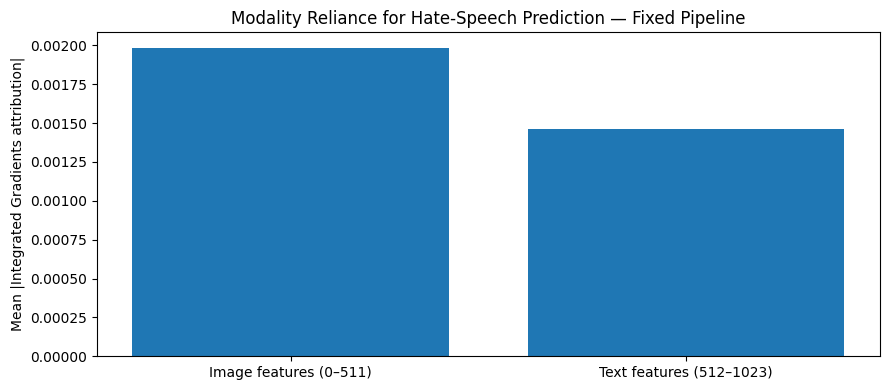


Saved: /content/Multi3Hate/figures/ig_modality_reliance_fixed.png


In [15]:
#@title 13A. Integrated Gradients — modality reliance on corrected data

from captum.attr import IntegratedGradients

# A wrapper around the trained hate-speech classifier only.
# The culture adversary is not part of the inference decision.
class HateOnlyHead(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.encoder = model.encoder
        self.classifier = model.classifier

    def forward(self, features):
        return self.classifier(self.encoder(features))


explain_model = HateOnlyHead(trainer_model).to(device).eval()
ig = IntegratedGradients(explain_model)

# Use the first test batch, as in the requested analysis cell.
sample_batch = next(iter(test_loader))

# CLIP features are intentionally detached from the frozen backbone.
features = get_clip_features(
    sample_batch["image"],
    sample_batch["text"]
).detach()

features.requires_grad_(True)

baseline_input = torch.zeros_like(features)

# Target class 1 = hate.
attributions, delta = ig.attribute(
    features,
    baselines=baseline_input,
    target=1,
    return_convergence_delta=True,
    n_steps=50,
)

print(f"Mean convergence delta: {delta.abs().mean().item():.6f}")

attr_np = attributions.detach().cpu().numpy()

img_attr = attr_np[:, :512]
txt_attr = attr_np[:, 512:]

mean_image_attr = float(np.abs(img_attr).mean())
mean_text_attr = float(np.abs(txt_attr).mean())
ratio = mean_text_attr / max(mean_image_attr, 1e-12)

print(f"Mean |attribution|, image half : {mean_image_attr:.6f}")
print(f"Mean |attribution|, text half  : {mean_text_attr:.6f}")
print(f"Ratio (text / image)           : {ratio:.3f}")

# Per-culture values for this batch
per_culture_modality = {}

for culture in sorted(set(sample_batch["culture"])):
    mask = np.asarray(sample_batch["culture"]) == culture
    if mask.sum() == 0:
        continue

    per_culture_modality[culture] = {
        "image_attr": float(np.abs(img_attr[mask]).mean()),
        "text_attr": float(np.abs(txt_attr[mask]).mean()),
    }

print("\nPer-culture image vs text reliance (first test batch):")
for culture, vals in per_culture_modality.items():
    print(
        f"  {culture}: "
        f"image={vals['image_attr']:.6f} | "
        f"text={vals['text_attr']:.6f}"
    )

# Save a compact result table
ig_culture_df = pd.DataFrame(per_culture_modality).T.reset_index()
ig_culture_df = ig_culture_df.rename(columns={"index": "culture"})
ig_culture_df.to_csv(
    RESULTS_DIR / "ig_modality_reliance_per_culture_first_batch.csv",
    index=False
)

# Plot modality reliance
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    ["Image features (0–511)", "Text features (512–1023)"],
    [mean_image_attr, mean_text_attr]
)
ax.set_ylabel("Mean |Integrated Gradients attribution|")
ax.set_title("Modality Reliance for Hate-Speech Prediction — Fixed Pipeline")
plt.tight_layout()

ig_fig_path = FIGURES_DIR / "ig_modality_reliance_fixed.png"
plt.savefig(ig_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:", ig_fig_path)

## 14. Qualitative error analysis

The next cell is the requested **Cell B**. It does not retrain anything.

It compares the predictions of:
- the independently trained no-adversary baseline, and
- the proposed adversarially debiased model

on exactly the same grouped test set.

It reports:
- number and percentage of disagreements,
- cases where the proposed model fixes a baseline error,
- cases where the proposed model introduces a new error,
- culture distribution of both types,
- up to four concrete examples of each type,
- and a complete CSV of all disagreements.

In [16]:
#@title 14B. Qualitative Error Analysis — baseline vs proposed

test_meme_ids = test_data["meme_id"].values
test_cultures_arr = test_data["culture"].values
test_texts = test_data["original_text"].values
test_true_labels = test_data["label"].values

proposed_preds = np.asarray(test_metrics["predictions"])
baseline_preds = np.asarray(baseline_results["predictions"])

assert len(proposed_preds) == len(test_meme_ids) == len(baseline_preds), (
    "Length mismatch — verify the test split and model evaluation order."
)

disagree_mask = proposed_preds != baseline_preds

print(
    f"Models disagree on {disagree_mask.sum()} / {len(proposed_preds)} "
    f"test samples ({disagree_mask.mean():.1%})"
)

disagreements = pd.DataFrame({
    "meme_id": test_meme_ids[disagree_mask],
    "culture": test_cultures_arr[disagree_mask],
    "text": test_texts[disagree_mask],
    "true_label": test_true_labels[disagree_mask],
    "baseline_pred": baseline_preds[disagree_mask],
    "proposed_pred": proposed_preds[disagree_mask],
})

disagreements["proposed_correct"] = (
    disagreements["proposed_pred"] == disagreements["true_label"]
)
disagreements["baseline_correct"] = (
    disagreements["baseline_pred"] == disagreements["true_label"]
)

proposed_fixes = disagreements[
    disagreements["proposed_correct"] & ~disagreements["baseline_correct"]
].copy()

new_errors = disagreements[
    ~disagreements["proposed_correct"] & disagreements["baseline_correct"]
].copy()

print(
    "\nProposed model correct / baseline wrong:",
    len(proposed_fixes)
)
print(
    "Baseline correct / proposed wrong:",
    len(new_errors)
)

print("\nBy culture — proposed model corrects a baseline error:")
if len(proposed_fixes):
    print(proposed_fixes["culture"].value_counts())
else:
    print("No such disagreements.")

print("\nBy culture — proposed model introduces a new error:")
if len(new_errors):
    print(new_errors["culture"].value_counts())
else:
    print("No such disagreements.")

def label_name(x):
    return "hate" if int(x) == 1 else "non-hate"

print("\n" + "=" * 80)
print("SAMPLE CASES WHERE THE PROPOSED MODEL CORRECTS A BASELINE ERROR")
print("=" * 80)

for _, row in proposed_fixes.head(4).iterrows():
    print(f"\n[meme_id={row['meme_id']}, culture={row['culture']}, "
          f"true_label={label_name(row['true_label'])}]")
    print(f"  Text: {str(row['text'])[:300]}")
    print(
        f"  Baseline: {label_name(row['baseline_pred'])} (wrong) | "
        f"Proposed: {label_name(row['proposed_pred'])} (correct)"
    )

print("\n" + "=" * 80)
print("SAMPLE CASES WHERE THE PROPOSED MODEL INTRODUCES A NEW ERROR")
print("=" * 80)

for _, row in new_errors.head(4).iterrows():
    print(f"\n[meme_id={row['meme_id']}, culture={row['culture']}, "
          f"true_label={label_name(row['true_label'])}]")
    print(f"  Text: {str(row['text'])[:300]}")
    print(
        f"  Baseline: {label_name(row['baseline_pred'])} (correct) | "
        f"Proposed: {label_name(row['proposed_pred'])} (wrong)"
    )

# Save the complete disagreement table.
disagreement_path = RESULTS_DIR / "qualitative_disagreements.csv"
disagreements.to_csv(disagreement_path, index=False)

print("\nSaved full disagreement table to:")
print(disagreement_path)

Models disagree on 22 / 225 test samples (9.8%)

Proposed model correct / baseline wrong: 12
Baseline correct / proposed wrong: 10

By culture — proposed model corrects a baseline error:
culture
US    5
DE    3
MX    3
CN    1
Name: count, dtype: int64

By culture — proposed model introduces a new error:
culture
IN    4
MX    2
DE    2
US    1
CN    1
Name: count, dtype: int64

SAMPLE CASES WHERE THE PROPOSED MODEL CORRECTS A BASELINE ERROR

[meme_id=15, culture=US, true_label=non-hate]
  Text: IVY   30 YEARS LATER
  Baseline: hate (wrong) | Proposed: non-hate (correct)

[meme_id=113, culture=US, true_label=hate]
  Text: You are good at the olympics   but terrible at money management.
  Baseline: non-hate (wrong) | Proposed: hate (correct)

[meme_id=148, culture=US, true_label=hate]
  Text: have you ever been   with a jew?
  Baseline: non-hate (wrong) | Proposed: hate (correct)

[meme_id=180, culture=US, true_label=hate]
  Text: SEES UNACCEPTABLE MUSLIM MEME   WISHES THEY COULD PROVIDE

In [17]:
#@title 15. Compact paper-ready summary of A + B

summary = {
    "test_n": len(test_data),
    "proposed_accuracy": float(test_metrics["hate_acc"]),
    "baseline_accuracy": float(baseline_results["overall_acc"]),
    "accuracy_difference": float(
        test_metrics["hate_acc"] - baseline_results["overall_acc"]
    ),
    "proposed_bias_gap": float(bias_gap),
    "baseline_bias_gap": float(baseline_gap),
    "bias_gap_reduction": float(baseline_gap - bias_gap),
    "n_disagreements": int(disagree_mask.sum()),
    "disagreement_rate": float(disagree_mask.mean()),
    "proposed_fixes": int(len(proposed_fixes)),
    "new_errors": int(len(new_errors)),
    "ig_mean_image_attribution": mean_image_attr,
    "ig_mean_text_attribution": mean_text_attr,
    "ig_text_image_ratio": ratio,
    "ig_mean_convergence_delta": float(delta.abs().mean().item()),
}

summary_df = pd.DataFrame([summary])
display(summary_df.T.rename(columns={0: "value"}))

summary_path = RESULTS_DIR / "ig_error_analysis_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved summary:", summary_path)
print("\nAll requested analyses completed.")

,value
test_n,225.000000
proposed_accuracy,0.680000
baseline_accuracy,0.671111
accuracy_difference,0.008889
proposed_bias_gap,0.244444
baseline_bias_gap,0.222222
bias_gap_reduction,-0.022222
n_disagreements,22.000000
disagreement_rate,0.097778
proposed_fixes,12.000000


Saved summary: /content/Multi3Hate/results/ig_error_analysis_summary.csv

All requested analyses completed.


# Expected execution order

Run the notebook **top to bottom**.

### GPU requirement
Integrated Gradients and model evaluation are GPU-friendly, and the fallback training path is
also designed for a Colab GPU.

### If you already have the final debiased checkpoint
The notebook will automatically load:

`/content/Multi3Hate/models/adversarial_debiased_model_best.pt`

### Baseline
If the baseline checkpoint is absent, it will train the independent baseline and save:

`/content/Multi3Hate/models/baseline_model_best.pt`

### Important interpretation point
Do **not** copy the old Integrated Gradients numbers into the paper before running this notebook.
The values produced here are the values to report from the corrected real-image + real-caption
pipeline.

Likewise, use the actual disagreement count and concrete meme examples printed by Cell 14B rather
than assuming the previously discussed `25 / 225` figure unless this run reproduces it.